In [4]:
import sys
import inspect
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import scipy.integrate as sint

from scipy import integrate
from scipy import optimize
from scipy import stats
from scipy import special
def fit_and_plot(fitfunc, x, y, 
                 p0=None, bounds=(-np.inf, np.inf),
                 figsize=None,
                 xlabel="x", ylabel="y", title="Model vs. Data", 
                 xlim=None, ylim=None, 
                 residual=False, 
                 adjusted=False,
                 filename=None):

    # get the fit and the error
    fit, cov = optimize.curve_fit(fitfunc, x, y, p0=p0, bounds=bounds)
    err = 2*np.sqrt(np.diag(cov))
    ypr = fitfunc(x, *fit)

    if residual:
        myfigsize=(10,3.5) if figsize is None else figsize
        fig, (ax1, ax2) = plt.subplots(1,2, figsize=myfigsize)
    else:
        myfigsize=(5,3.5) if figsize is None else figsize
        fig, ax1 = plt.subplots(1,1, figsize=myfigsize)
    
    # plot data and model
    ax1.plot(x, y, 's', label='data')
    ax1.plot(x, ypr, '-', label='model')
    ax1.set_xlabel(xlabel)
    ax1.set_ylabel(ylabel)
    ax1.set_title(title)
    if xlim is not None:  ax1.set_xlim(xlim)
    if ylim is not None:  ax1.set_ylim(ylim)
    ax1.legend(loc='best')

    # plot residual
    if residual:
        res = y - ypr
        
        ax2.plot(x, res, 's')
        ax2.plot(x, 0*x, 'k--')
        ax2.set_xlabel('x')
        ax2.set_ylabel('r')
        ax2.set_title('Residual')
        y1min, y1max = ax1.get_ylim()
        y1span = y1max-y1min
        ax2.set_ylim(-y1span/2, y1span/2)
   
    
    fig.tight_layout()
    if filename is not None:  plt.savefig(filename)
    

    # create the text report summarizing the fit
    fittext1 = ""
    
    # get the parameter names and report their values
    pnames = inspect.getfullargspec(fitfunc)[0][1:]
    #fittext += "Parameter Values: 95% confidence\n"
    #fittext += "\n"
    for (a, e, p) in zip(fit, err, pnames):
        fittext1 += "%4s = %8.5f +- %8.5f  (rel: %3.3f%%)\n" % (p, a, e, 100*e/np.abs(a))

    # calculate absolute / adjusted R-squared
    fittext2 = ""
    N = len(x)
    P = len(fit)
    yav = np.mean(y)
    ssres = np.sum((y-ypr)**2)
    sstot = np.sum((y-yav)**2)
    uvr   = ssres / sstot
    auvr  = uvr * (N-1)/(N-P)
    evr   = 1 - uvr
    aevr  = 1 - auvr
    
    if adjusted:
        fittext2 += 'Unexplained Variance (adj): %1.5f\n' % auvr
        fittext2 += 'Explained Variance (adj):   %1.5f' % aevr 
    else:
        fittext2 += 'Unexplained Variance (raw): %1.5f\n' % uvr
        fittext2 += 'Explained Variance (raw):   %1.5f' % evr 


    # resize the figure for inline display
    if residual:
        fig.set_size_inches(10, 4.5)
        plt.subplots_adjust(bottom=0.3)
        plt.figtext(0.07, 0.18, fittext1, va='top', fontsize=10, fontfamily='monospace')
        plt.figtext(0.6, 0.18, fittext2, va='top', fontsize=10, fontfamily='monospace')
    else:
        fig.set_size_inches(5, 4.5)
        plt.subplots_adjust(bottom=0.3)
        plt.figtext(0.1, 0.18, fittext1, va='top', fontsize=10, fontfamily='monospace')
    plt.show()

    # return the fitted values and the uncertainties
    return fit, err



In [6]:
Excel_file = 'Stock_Pandas.xlsx'
data = pd.read_excel(Excel_file)
data.head()

,RSI,Stock,STOCH
0,-2.33,-0.48,-2.13
1,-12.55,-5.26,-3.27
2,9.54,2.84,3.65
3,0.38,74.22,-0.08
4,9.88,12.95,23.12


In [10]:
STOCH = np.array(data['STOCH'])
Stock = np.array(data['Stock'])
RSI = np.array(data['RSI'])
RSILow = np.array(RSI[0:15])
RSIHigh = np.array(RSI[16:30])
StockLow = np.array(Stock[0:15])
StockHigh = np.array(Stock[16:30])
STOCHLow = np.array(STOCH[0:15])
STOCHHigh = np.array(STOCH[16:30])

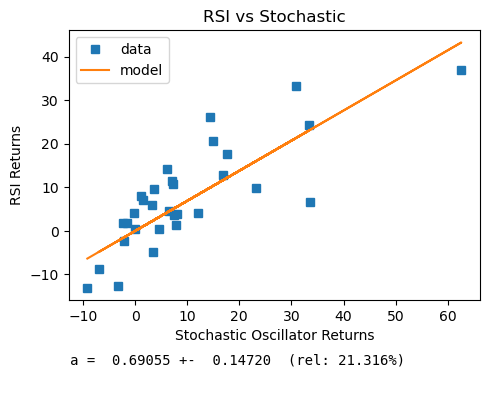

In [12]:
def model(x, a):
    return a * x

fit = fit_and_plot(model, STOCH, RSI,xlabel='Stochastic Oscillator Returns', ylabel='RSI Returns',title='RSI vs Stochastic',
                   residual = False)

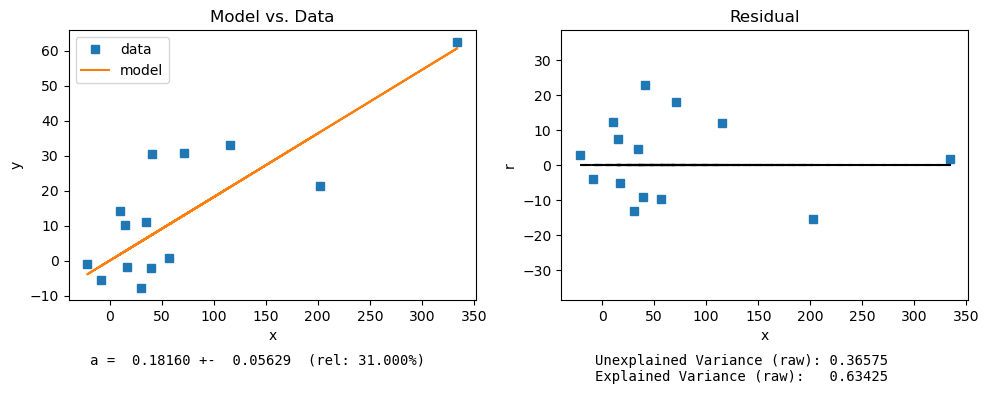

In [218]:
fit = fit_and_plot(model, StockHigh, STOCHHigh, residual = True)

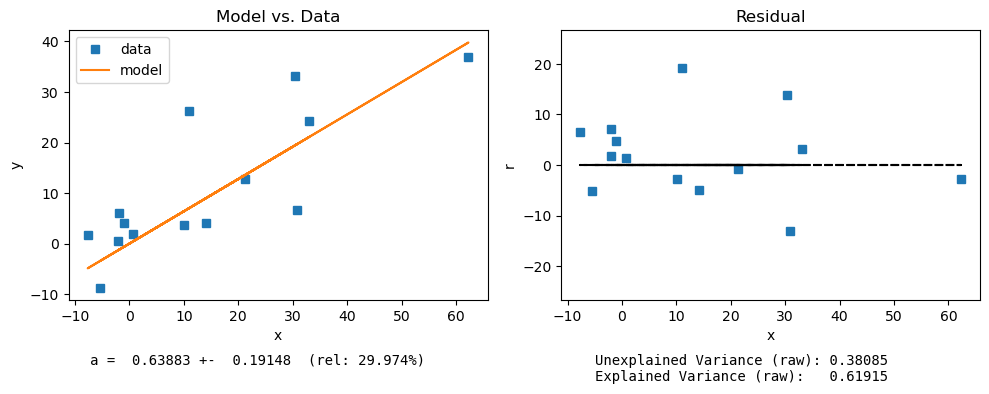

In [175]:
fit = fit_and_plot(model, STOCHHigh, RSIHigh, residual = True)

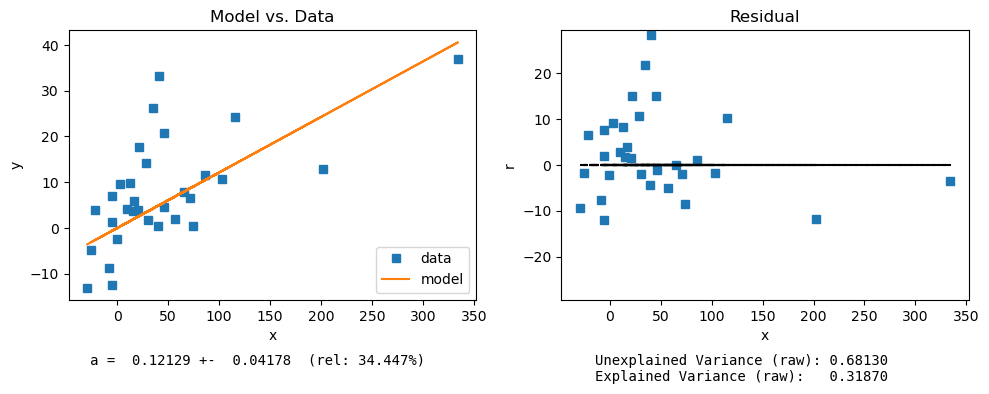

In [195]:
fit = fit_and_plot(model, Stock, RSI, residual = True)

In [16]:
np.mean(STOCHHigh)

14.849285714285712

In [193]:
4.5 + ((0.10203) * (27.904 - 4.5))

6.88791012

In [191]:
STOCHLow.mean()

5.508000000000001

In [199]:
4.5 + ((0.12129) * (44.2771 - 4.5))

9.324564459

In [203]:
RSI.mean()

7.738064516129031